In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Plot settings
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# FlowOpt colour palette
COLORS = {
    'navy':   '#0B2A4A',
    'teal':   '#0D7377',
    'green':  '#1A9E5C',
    'purple': '#9B59B6',
    'orange': '#E67E22',
    'red':    '#C0392B',
    'white':  '#FFFFFF',
    'light':  '#F4F8FB',
}

# Absolute paths
BASE      = 'C:/Users/MSI/flowopt'
IMMR_PATH = os.path.join(
    BASE, 'data', 'immr',
    'FlowOpt_IMMR_Complete.xlsx')
AHB_PATH  = os.path.join(
    BASE, 'data', 'immr',
    'FlowOpt_SriLanka_AHB_Data.xlsx')
PROCESSED = os.path.join(
    BASE, 'data', 'processed')

os.makedirs(PROCESSED, exist_ok=True)

print("✅ All imports successful")
print(f"pandas:  {pd.__version__}")
print(f"numpy:   {np.__version__}")
print(f"seaborn: {sns.__version__}")

✅ All imports successful
pandas:  2.3.3
numpy:   2.4.6
seaborn: 0.13.2


In [2]:
# ── Load IMMR ─────────────────────────────────────────
df_immr = pd.read_excel(
    IMMR_PATH,
    sheet_name='1_Annual_Totals',
    skiprows=1)
df_immr.columns = (
    df_immr.columns.str.strip())
df_immr = df_immr[
    pd.to_numeric(
        df_immr['Year'],
        errors='coerce').notna()]
df_immr['Year'] = (
    df_immr['Year'].astype(int))
df_immr = df_immr[
    (df_immr['Year'] >= 2013) &
    (df_immr['Year'] <= 2024)].copy()
df_immr = df_immr.rename(columns={
    'Year':             'year',
    'Total Inpatients': 'inpat',
    'Disc TOTAL':       'disc_t',
    'Deaths TOTAL':     'death_t',
    'Disc Male':        'disc_male',
    'Disc Female':      'disc_female',
    'Deaths Male':      'death_male',
    'Deaths Female':    'death_female',
    'Death Rate %':     'death_rate',
    'YoY Change %':     'yoy_change',
})
for col in ['inpat','disc_t',
            'death_t','death_rate']:
    df_immr[col] = pd.to_numeric(
        df_immr[col], errors='coerce')
df_immr = df_immr.sort_values(
    'year').reset_index(drop=True)

print("✅ IMMR loaded:", df_immr.shape)
print(df_immr[[
    'year','inpat','disc_t',
    'death_t','death_rate']])
print()

# ── Load AHB Bed Occupancy ────────────────────────────
df_bor = pd.read_excel(
    AHB_PATH,
    sheet_name='2_Bed_Occupancy',
    skiprows=1)
df_bor.columns = (
    df_bor.columns.str.strip())
df_bor = df_bor[
    pd.to_numeric(
        df_bor['Year'],
        errors='coerce').notna()]
df_bor['Year'] = (
    df_bor['Year'].astype(int))
df_bor = df_bor[
    (df_bor['Year'] >= 2013) &
    (df_bor['Year'] <= 2024)].copy()
df_bor = df_bor.rename(columns={
    'Year': 'year',
    'Total Hospital Beds': 'beds',
    'Bed Occupancy Rate (BOR) %':
        'bor',
    'Average Duration of Stay '
    '(ADOS) Days': 'ados',
    'Bed Turnover Rate (BTR)':
        'btr',
    'Beds per 1,000 Population':
        'beds_per_1000',
})
for col in ['beds','bor','ados']:
    df_bor[col] = pd.to_numeric(
        df_bor[col], errors='coerce')
df_bor = df_bor.sort_values(
    'year').reset_index(drop=True)

print("✅ BOR/ADOS loaded:",
    df_bor.shape)
print(df_bor[['year','bor',
    'ados','beds']])
print()

# ── Load AHB OPD ──────────────────────────────────────
df_opd = pd.read_excel(
    AHB_PATH,
    sheet_name='3_OPD_Attendance',
    skiprows=1)
df_opd.columns = (
    df_opd.columns.str.strip())
df_opd = df_opd[
    pd.to_numeric(
        df_opd['Year'],
        errors='coerce').notna()]
df_opd['Year'] = (
    df_opd['Year'].astype(int))
df_opd = df_opd[
    (df_opd['Year'] >= 2013) &
    (df_opd['Year'] <= 2024)].copy()
df_opd = df_opd.rename(columns={
    'Year': 'year',
    'Total OPD Visits '
    '(All Hospitals)': 'opd',
})
df_opd['opd'] = pd.to_numeric(
    df_opd['opd'], errors='coerce')
df_opd = df_opd.sort_values(
    'year').reset_index(drop=True)

print("✅ OPD loaded:", df_opd.shape)
print(df_opd[['year','opd']])
print()

# ── Merge all into master ─────────────────────────────
df = df_immr[[
    'year','inpat','disc_t',
    'death_t','death_rate']].merge(
    df_bor[['year','bor',
        'ados','beds']],
    on='year', how='left').merge(
    df_opd[['year','opd']],
    on='year', how='left')

print("✅ Master dataset:", df.shape)
print(df)

✅ IMMR loaded: (12, 11)
    year      inpat     disc_t  death_t  death_rate
0   2013  5926125.0  5881886.0  44239.0         1.0
1   2014  6120470.0  6073053.0  47417.0         1.0
2   2015  6359681.0  6311873.0  47808.0         1.0
3   2016  6497773.0  6449753.0  48020.0         1.0
4   2017  6910249.0  6857911.0  52338.0         1.0
5   2018  7116268.0  7063097.0  53171.0         1.0
6   2019  7477860.0  7418884.0  58976.0         1.0
7   2020  5785147.0  5737317.0  47830.0         1.0
8   2021  5314193.0  5250335.0  63858.0         1.0
9   2022  6350347.0  6283849.0  66498.0         1.0
10  2023  6949732.0  6882377.0  67355.0         1.0
11  2024  7194899.0  7126598.0  68301.0         1.0

✅ BOR/ADOS loaded: (12, 6)
    year   bor  ados     beds
0   2013  72.1   3.9  83275.0
1   2014  72.5   3.7  84728.0
2   2015  73.2   3.6  84728.0
3   2016  74.1   3.6  86589.0
4   2017  75.0   3.5  86589.0
5   2018  76.2   3.5  87280.0
6   2019  77.1   3.5  87280.0
7   2020  48.4   3.1  87280.0
8 

In [3]:
cols = ['inpat','disc_t','death_t',
        'death_rate','bor','ados',
        'beds','opd']

print("DESCRIPTIVE STATISTICS")
print("="*70)
stats = df[cols].describe().round(2)
print(stats.to_string())
print()

print("YEAR RANGE:", 
    df['year'].min(), "—",
    df['year'].max())
print("TOTAL RECORDS:", len(df))
print()

# Key figures
print("KEY STATISTICS:")
print(f"  Max Inpatients: "
    f"{df['inpat'].max():,.0f} "
    f"({df.loc[df['inpat'].idxmax(),'year']})")
print(f"  Min Inpatients: "
    f"{df['inpat'].min():,.0f} "
    f"({df.loc[df['inpat'].idxmin(),'year']})")
print(f"  Max BOR: "
    f"{df['bor'].max():.1f}% "
    f"({df.loc[df['bor'].idxmax(),'year']})")
print(f"  Min BOR: "
    f"{df['bor'].min():.1f}% "
    f"({df.loc[df['bor'].idxmin(),'year']})")
print(f"  Max OPD: "
    f"{df['opd'].max():,.0f} "
    f"({df.loc[df['opd'].idxmax(),'year']})")
print(f"  Min OPD: "
    f"{df['opd'].min():,.0f} "
    f"({df.loc[df['opd'].idxmin(),'year']})")

DESCRIPTIVE STATISTICS
            inpat      disc_t   death_t  death_rate    bor   ados      beds          opd
count       12.00       12.00     12.00        12.0  12.00  12.00     12.00        12.00
mean   6500228.67  6444744.42  55484.25         1.0  70.07   3.48  87284.00  25914764.75
std     648218.71   645548.38   8988.94         0.0   8.11   0.21   2371.27   3889571.82
min    5314193.00  5250335.00  44239.00         1.0  48.40   3.10  83275.00  19635994.00
25%    6071883.75  6025261.25  47824.50         1.0  70.38   3.38  86123.75  23177001.00
50%    6428727.00  6380813.00  52754.50         1.0  72.50   3.50  87280.00  26094945.00
75%    6991366.00  6927557.00  64518.00         1.0  74.32   3.60  88750.00  28461231.25
max    7477860.00  7418884.00  68301.00         1.0  77.10   3.90  91159.00  31545497.00

YEAR RANGE: 2013 — 2024
TOTAL RECORDS: 12

KEY STATISTICS:
  Max Inpatients: 7,477,860 (2019)
  Min Inpatients: 5,314,193 (2021)
  Max BOR: 77.1% (2019)
  Min BOR: 48.4% (2020

In [4]:
print("MISSING VALUE ANALYSIS")
print("="*40)

missing = df.isnull().sum()
missing_pct = (
    df.isnull().sum() / len(df) * 100)

df_missing = pd.DataFrame({
    'Column': df.columns,
    'Missing': missing.values,
    'Missing %': missing_pct.values.round(1),
    'Available': (
        len(df) - missing).values,
})

print(df_missing.to_string(index=False))
print()

if missing.sum() == 0:
    print("✅ No missing values found!")
    print("   Dataset is complete for "
          "all 12 years (2013–2024)")
else:
    print(f"⚠️  Total missing: "
          f"{missing.sum()}")

MISSING VALUE ANALYSIS
    Column  Missing  Missing %  Available
      year        0        0.0         12
     inpat        0        0.0         12
    disc_t        0        0.0         12
   death_t        0        0.0         12
death_rate        0        0.0         12
       bor        0        0.0         12
      ados        0        0.0         12
      beds        0        0.0         12
       opd        0        0.0         12

✅ No missing values found!
   Dataset is complete for all 12 years (2013–2024)


In [5]:
df_yoy = df.copy()

indicators = {
    'inpat':   'Total Inpatients',
    'disc_t':  'Discharges',
    'death_t': 'Deaths',
    'bor':     'BOR %',
    'ados':    'ADOS days',
    'opd':     'OPD Visits',
    'beds':    'Hospital Beds',
}

for col in indicators.keys():
    df_yoy[f'{col}_yoy'] = (
        df_yoy[col].pct_change() * 100)

print("YEAR-ON-YEAR CHANGE (%)")
print("="*80)

yoy_cols = [
    f'{c}_yoy' for c in indicators]
df_display = df_yoy[
    ['year'] + yoy_cols].copy()
df_display.columns = (
    ['Year'] +
    list(indicators.values()))

print(df_display.to_string(
    index=False, float_format='{:.1f}%'.format))
print()

# COVID impact
print("COVID-19 IMPACT (2020 vs 2019):")
for col, label in indicators.items():
    val_2019 = df[
        df['year']==2019][col].values[0]
    val_2020 = df[
        df['year']==2020][col].values[0]
    change = (
        (val_2020-val_2019)/val_2019*100)
    direction = "▼" if change < 0 else "▲"
    print(f"  {direction} {label}: "
          f"{change:.1f}%")

YEAR-ON-YEAR CHANGE (%)
 Year  Total Inpatients  Discharges  Deaths  BOR %  ADOS days  OPD Visits  Hospital Beds
 2013               NaN         NaN     NaN    NaN        NaN         NaN            NaN
 2014              3.3%        3.3%    7.2%   0.6%      -5.1%        6.9%           1.7%
 2015              3.9%        3.9%    0.8%   1.0%      -2.7%        7.1%           0.0%
 2016              2.2%        2.2%    0.4%   1.2%       0.0%        6.7%           2.2%
 2017              6.3%        6.3%    9.0%   1.2%      -2.8%        8.7%           0.0%
 2018              3.0%        3.0%    1.6%   1.6%       0.0%        6.8%           0.8%
 2019              5.1%        5.0%   10.9%   1.2%       0.0%       13.2%           0.0%
 2020            -22.6%      -22.7%  -18.9% -37.2%     -11.4%      -25.8%           0.0%
 2021             -8.1%       -8.5%   33.5%  24.4%       6.5%       11.5%           1.4%
 2022             19.5%       19.7%    4.1%  13.8%       3.0%        7.3%           1.

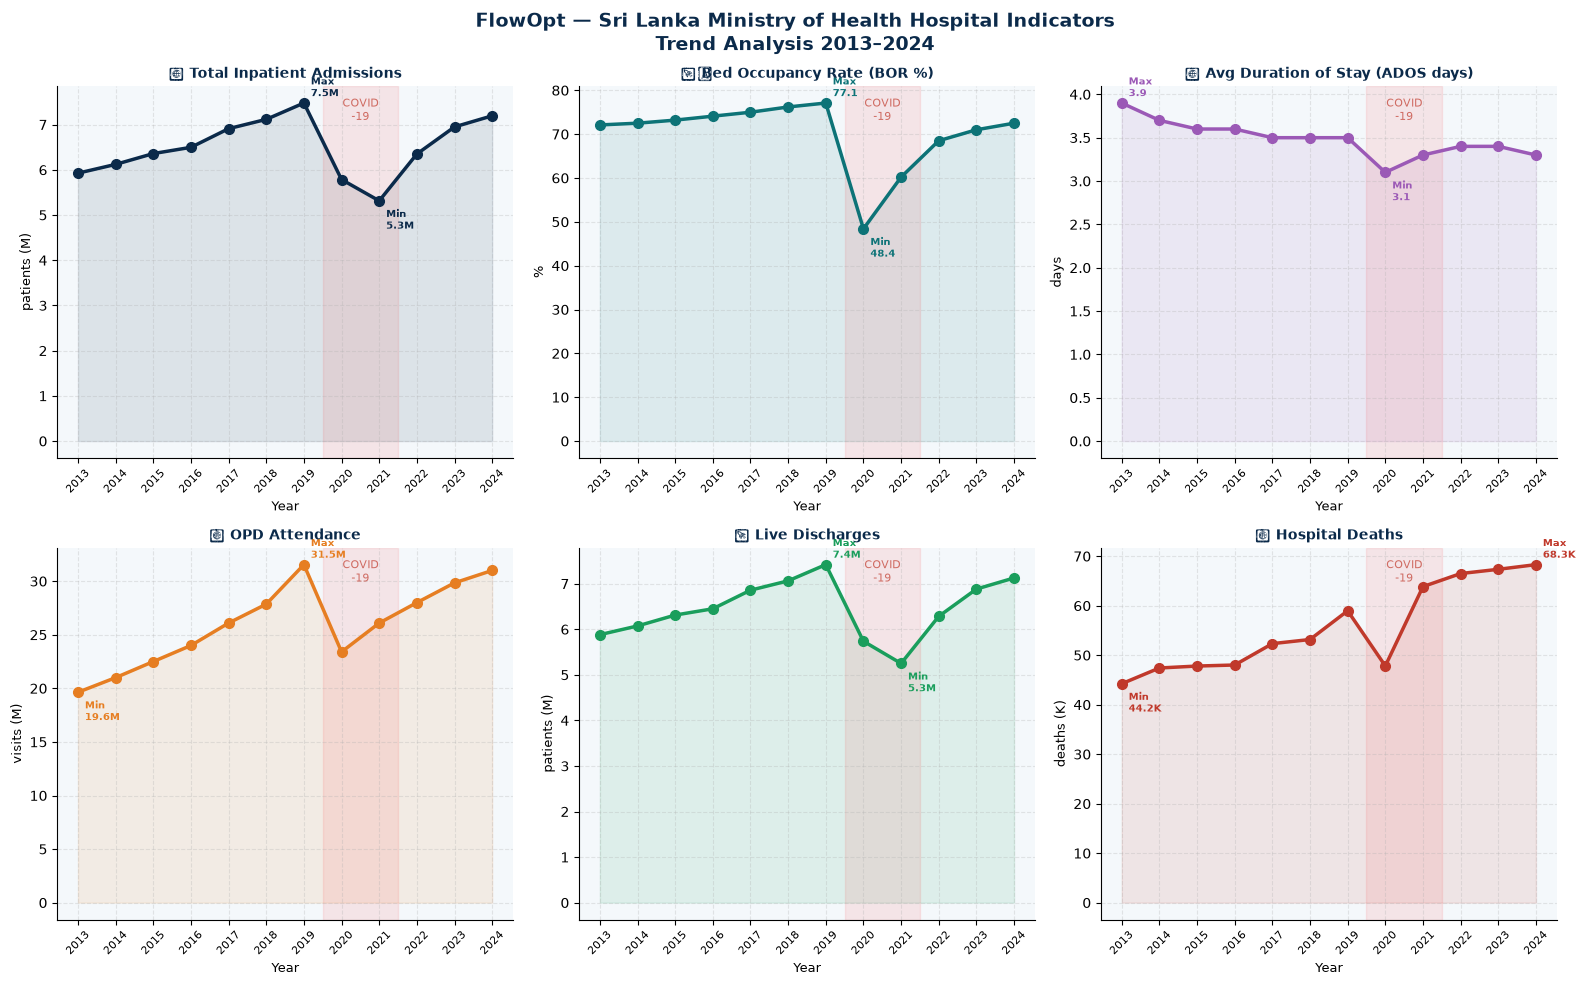

✅ Figure 1 saved:
  C:/Users/MSI/flowopt\data\processed\eda_fig1_trends.png


In [7]:
fig, axes = plt.subplots(
    2, 3, figsize=(16, 10)
)
axes = axes.flatten()

trends = [
    ('inpat', '🏥 Total Inpatient '
     'Admissions', COLORS['navy'],
     'patients', 1e6, 'M'),

    ('bor', '🛏️ Bed Occupancy '
     'Rate (BOR %)', COLORS['teal'],
     '%', 1, ''),

    ('ados', '📅 Avg Duration of '
     'Stay (ADOS days)',
     COLORS['purple'],
     'days', 1, ''),

    ('opd', '👥 OPD Attendance',
     COLORS['orange'],
     'visits', 1e6, 'M'),

    ('disc_t', '🚪 Live Discharges',
     COLORS['green'],
     'patients', 1e6, 'M'),

    ('death_t', '💀 Hospital Deaths',
     COLORS['red'],
     'deaths', 1e3, 'K'),
]

for ax, (col, title,
         color, unit,
         divisor, suffix) in zip(
         axes, trends):

    values = df[col] / divisor
    years = df['year']

    # Plot trend
    ax.plot(
        years,
        values,
        'o-',
        color=color,
        linewidth=2.5,
        markersize=7,
        zorder=3
    )

    # Fill area under the line
    ax.fill_between(
        years,
        values,
        alpha=0.1,
        color=color
    )

    # Shade COVID-19 period
    ax.axvspan(
        2019.5,
        2021.5,
        alpha=0.08,
        color='red'
    )

    ax.text(
        2020.5,
        values.max() * 0.95,
        'COVID\n-19',
        ha='center',
        fontsize=8,
        color=COLORS['red'],
        alpha=0.7
    )

    # Find maximum and minimum values
    max_idx = values.idxmax()
    min_idx = values.idxmin()

    # Annotate maximum value
    ax.annotate(
        f"Max\n{values[max_idx]:.1f}{suffix}",
        xy=(
            years[max_idx],
            values[max_idx]
        ),
        xytext=(5, 5),
        textcoords='offset points',
        fontsize=7,
        color=color,
        fontweight='bold'
    )

    # Annotate minimum value
    ax.annotate(
        f"Min\n{values[min_idx]:.1f}{suffix}",
        xy=(
            years[min_idx],
            values[min_idx]
        ),
        xytext=(5, -20),
        textcoords='offset points',
        fontsize=7,
        color=color,
        fontweight='bold'
    )

    # Titles and labels
    ax.set_title(
        title,
        fontweight='bold',
        color=COLORS['navy'],
        fontsize=10
    )

    ax.set_xlabel(
        'Year',
        fontsize=9
    )

    ax.set_ylabel(
        f'{unit} ({suffix})'
        if suffix else unit,
        fontsize=9
    )

    # Background and grid
    ax.set_facecolor(
        COLORS['light']
    )

    ax.grid(
        alpha=0.3,
        linestyle='--'
    )

    # X-axis years
    ax.set_xticks(years)

    ax.set_xticklabels(
        years,
        rotation=45,
        fontsize=8
    )


# Main figure title
fig.suptitle(
    'FlowOpt — Sri Lanka Ministry of '
    'Health Hospital Indicators\n'
    'Trend Analysis 2013–2024',
    fontsize=14,
    fontweight='bold',
    color=COLORS['navy']
)

plt.tight_layout()

# Save figure
save_path = os.path.join(
    PROCESSED,
    'eda_fig1_trends.png'
)

plt.savefig(
    save_path,
    dpi=150,
    bbox_inches='tight',
    facecolor='white'
)

plt.show()

print(
    f"✅ Figure 1 saved:\n  {save_path}"
)

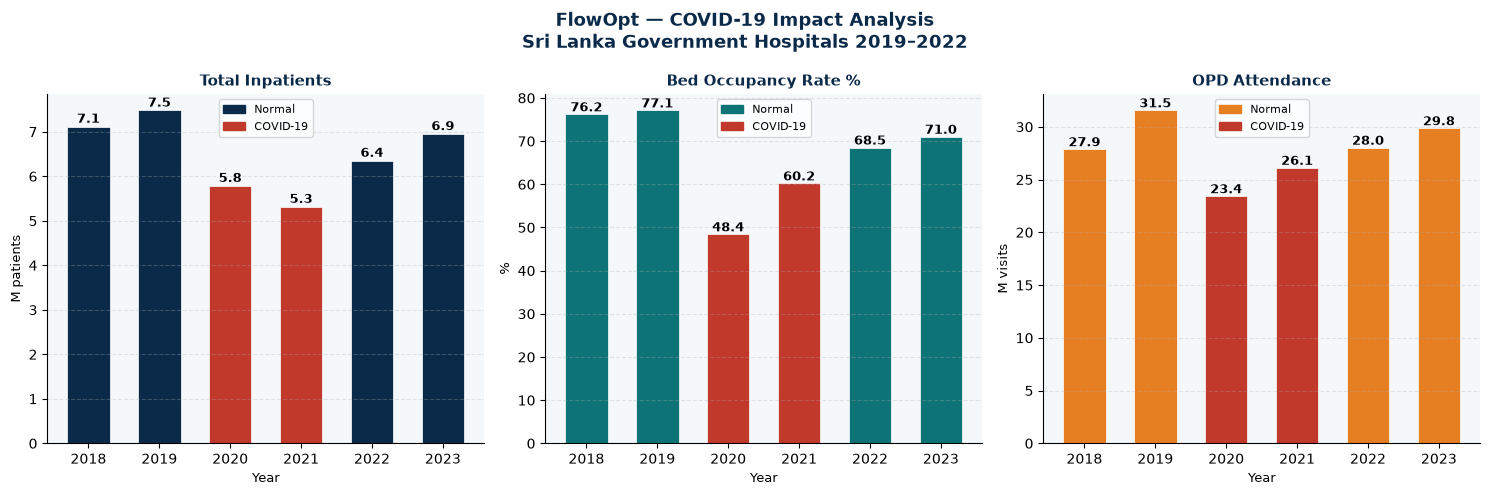

✅ Figure 2 saved:
  C:/Users/MSI/flowopt\data\processed\eda_fig2_covid_impact.png

COVID-19 IMPACT STATISTICS:
--------------------------------------------------

Total Inpatients:
  2019 (pre-COVID): 7.48 M patients
  2020 (COVID):     5.79 M patients
  Drop 2019→2020:   -22.6%
  2022 (recovery):  6.35 M patients
  Recovery 2020→22: +9.8%

Bed Occupancy Rate %:
  2019 (pre-COVID): 77.10 %
  2020 (COVID):     48.40 %
  Drop 2019→2020:   -37.2%
  2022 (recovery):  68.50 %
  Recovery 2020→22: +41.5%

OPD Attendance:
  2019 (pre-COVID): 31.55 M visits
  2020 (COVID):     23.40 M visits
  Drop 2019→2020:   -25.8%
  2022 (recovery):  28.00 M visits
  Recovery 2020→22: +19.6%


In [8]:
fig, axes = plt.subplots(
    1, 3, figsize=(15, 5))
fig.suptitle(
    'FlowOpt — COVID-19 Impact '
    'Analysis\nSri Lanka Government '
    'Hospitals 2019–2022',
    fontsize=13, fontweight='bold',
    color=COLORS['navy'])

covid_plots = [
    ('inpat', 'Total Inpatients',
     COLORS['navy'], 1e6, 'M patients'),
    ('bor',   'Bed Occupancy Rate %',
     COLORS['teal'], 1, '%'),
    ('opd',   'OPD Attendance',
     COLORS['orange'], 1e6, 'M visits'),
]

df_covid = df[
    (df['year'] >= 2018) &
    (df['year'] <= 2023)].copy()

for ax, (col, title,
         color, div, unit) in zip(
         axes, covid_plots):
    years  = df_covid['year']
    values = df_covid[col] / div

    bars = ax.bar(years, values,
        color=[
            COLORS['red']
            if y in [2020,2021]
            else color
            for y in years],
        edgecolor='white',
        linewidth=0.5,
        width=0.6)

    # Value labels
    for bar, val in zip(
            bars, values):
        ax.text(
            bar.get_x()
                + bar.get_width()/2,
            bar.get_height() + 0.02,
            f'{val:.1f}',
            ha='center', va='bottom',
            fontsize=9,
            fontweight='bold')

    ax.set_title(title,
        fontweight='bold',
        color=COLORS['navy'],
        fontsize=11)
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel(unit, fontsize=9)
    ax.set_facecolor(COLORS['light'])
    ax.grid(axis='y',
        alpha=0.3, linestyle='--')

    # Legend
    normal = mpatches.Patch(
        color=color, label='Normal')
    covid = mpatches.Patch(
        color=COLORS['red'],
        label='COVID-19')
    ax.legend(
        handles=[normal, covid],
        fontsize=8)

plt.tight_layout()
save_path = os.path.join(
    PROCESSED,
    'eda_fig2_covid_impact.png')
plt.savefig(save_path, dpi=150,
    bbox_inches='tight',
    facecolor='white')
plt.show()
print(f"✅ Figure 2 saved:\n  {save_path}")

# Print COVID statistics
print("\nCOVID-19 IMPACT STATISTICS:")
print("-"*50)
for col, label, _, div, unit in (
        covid_plots):
    v2019 = df[
        df['year']==2019
    ][col].values[0]
    v2020 = df[
        df['year']==2020
    ][col].values[0]
    v2021 = df[
        df['year']==2021
    ][col].values[0]
    v2022 = df[
        df['year']==2022
    ][col].values[0]
    drop = (v2020-v2019)/v2019*100
    rec  = (v2022-v2020)/v2020*100
    print(f"\n{label}:")
    print(f"  2019 (pre-COVID): "
          f"{v2019/div:.2f} {unit}")
    print(f"  2020 (COVID):     "
          f"{v2020/div:.2f} {unit}")
    print(f"  Drop 2019→2020:   "
          f"{drop:.1f}%")
    print(f"  2022 (recovery):  "
          f"{v2022/div:.2f} {unit}")
    print(f"  Recovery 2020→22: "
          f"+{rec:.1f}%")

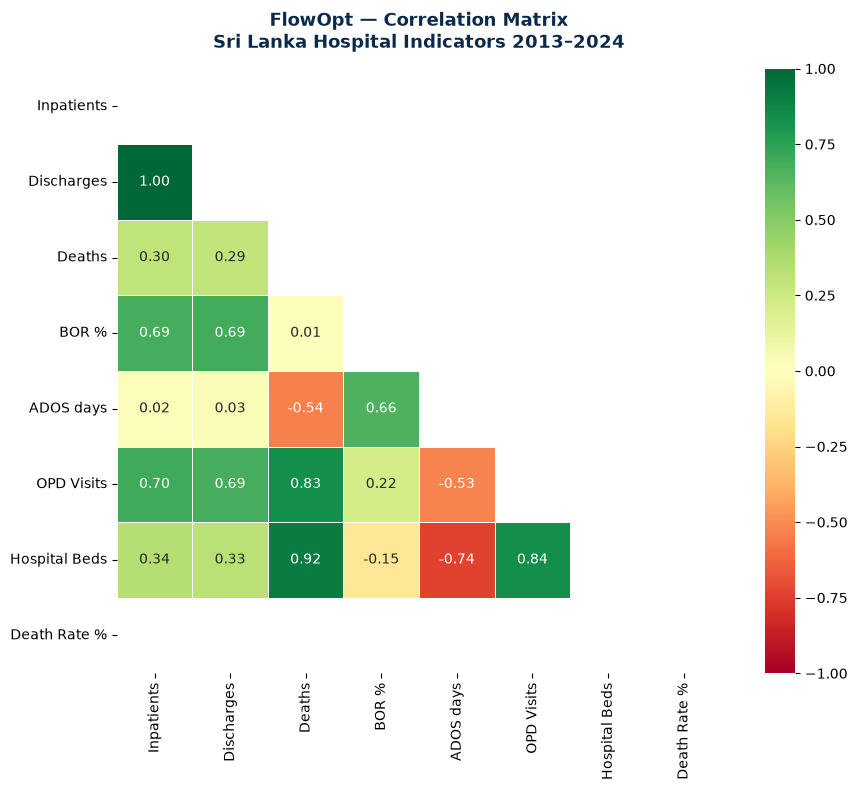

✅ Figure 3 saved:
  C:/Users/MSI/flowopt\data\processed\eda_fig3_correlation.png

STRONG CORRELATIONS (|r| > 0.8):
---------------------------------------------
  Inpatients ↔ Discharges: r=1.00 (positive)
  Deaths ↔ OPD Visits: r=0.83 (positive)
  Deaths ↔ Hospital Beds: r=0.92 (positive)
  OPD Visits ↔ Hospital Beds: r=0.84 (positive)


In [9]:
corr_cols = {
    'inpat':    'Inpatients',
    'disc_t':   'Discharges',
    'death_t':  'Deaths',
    'bor':      'BOR %',
    'ados':     'ADOS days',
    'opd':      'OPD Visits',
    'beds':     'Hospital Beds',
    'death_rate':'Death Rate %',
}

df_corr = df[
    list(corr_cols.keys())].copy()
df_corr.columns = (
    list(corr_cols.values()))

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(
    figsize=(10, 8))

mask = np.triu(
    np.ones_like(
        corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 10})

ax.set_title(
    'FlowOpt — Correlation Matrix\n'
    'Sri Lanka Hospital Indicators '
    '2013–2024',
    fontsize=13, fontweight='bold',
    color=COLORS['navy'],
    pad=15)

plt.tight_layout()
save_path = os.path.join(
    PROCESSED,
    'eda_fig3_correlation.png')
plt.savefig(save_path, dpi=150,
    bbox_inches='tight',
    facecolor='white')
plt.show()
print(f"✅ Figure 3 saved:\n  {save_path}")

# Strong correlations
print("\nSTRONG CORRELATIONS (|r| > 0.8):")
print("-"*45)
for i in range(len(corr_matrix)):
    for j in range(i+1,
            len(corr_matrix)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8:
            c1 = corr_matrix.columns[i]
            c2 = corr_matrix.columns[j]
            direction = "positive" \
                if r > 0 \
                else "negative"
            print(f"  {c1} ↔ {c2}: "
                  f"r={r:.2f} "
                  f"({direction})")

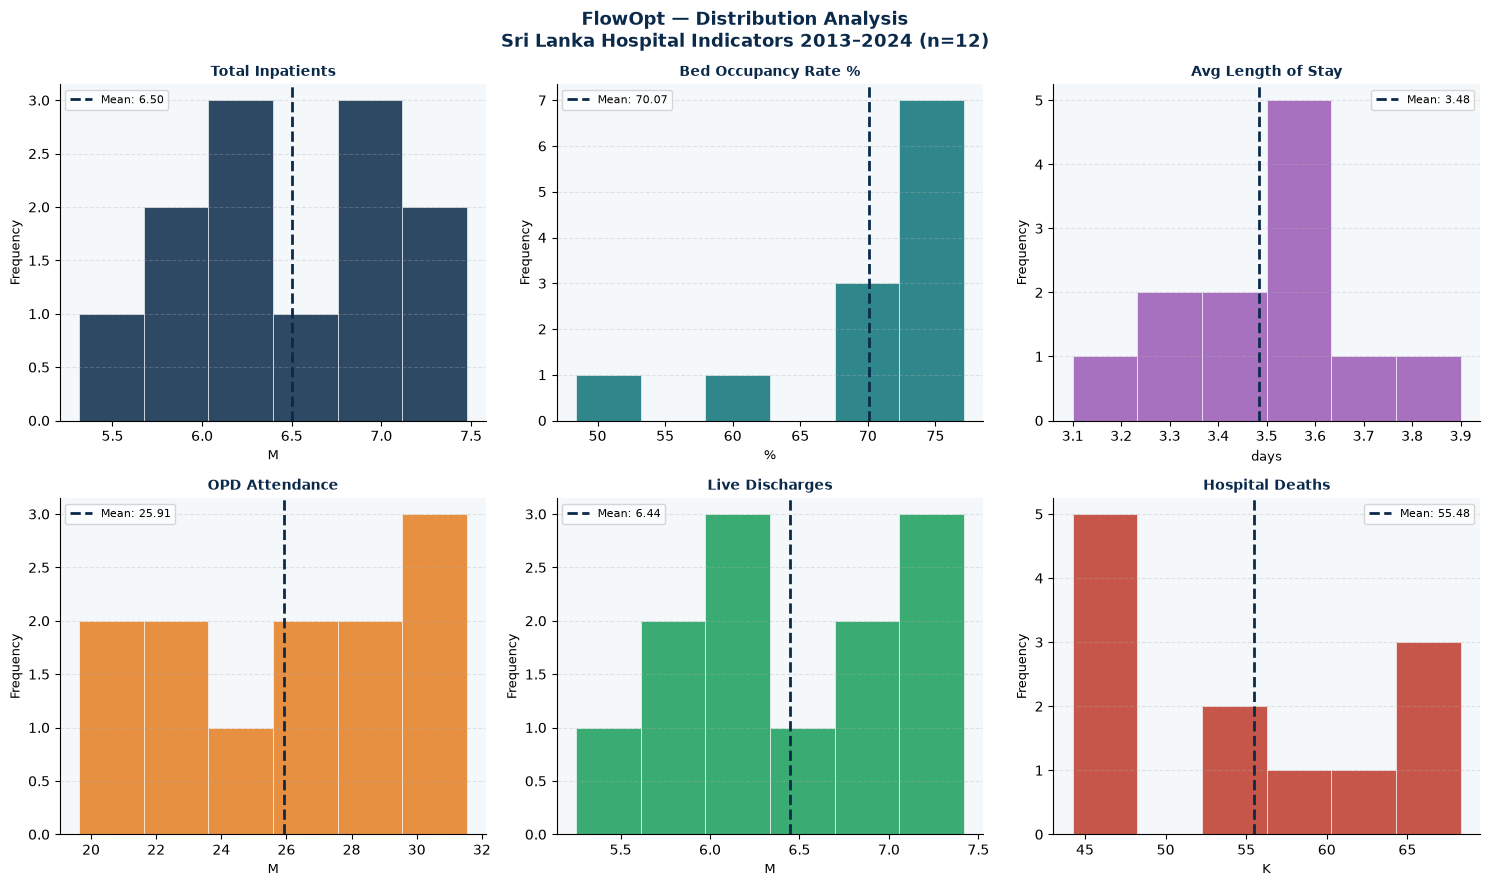

✅ Figure 4 saved:
  C:/Users/MSI/flowopt\data\processed\eda_fig4_distributions.png


In [10]:
fig, axes = plt.subplots(
    2, 3, figsize=(15, 9))
axes = axes.flatten()

dist_cols = [
    ('inpat',   'Total Inpatients',
     COLORS['navy'],   1e6, 'M'),
    ('bor',     'Bed Occupancy Rate %',
     COLORS['teal'],   1,   '%'),
    ('ados',    'Avg Length of Stay',
     COLORS['purple'], 1,   'days'),
    ('opd',     'OPD Attendance',
     COLORS['orange'], 1e6, 'M'),
    ('disc_t',  'Live Discharges',
     COLORS['green'],  1e6, 'M'),
    ('death_t', 'Hospital Deaths',
     COLORS['red'],    1e3, 'K'),
]

for ax, (col, title,
         color, div, unit) in zip(
         axes, dist_cols):
    values = df[col] / div

    ax.hist(values,
        bins=6,
        color=color,
        edgecolor='white',
        linewidth=0.5,
        alpha=0.85)

    mean_v = values.mean()
    ax.axvline(
        x=mean_v,
        color=COLORS['navy'],
        linestyle='--',
        linewidth=2,
        label=f'Mean: {mean_v:.2f}')

    ax.set_title(title,
        fontweight='bold',
        color=COLORS['navy'],
        fontsize=10)
    ax.set_xlabel(
        f'{unit}', fontsize=9)
    ax.set_ylabel(
        'Frequency', fontsize=9)
    ax.legend(fontsize=8)
    ax.set_facecolor(COLORS['light'])
    ax.grid(axis='y',
        alpha=0.3, linestyle='--')

fig.suptitle(
    'FlowOpt — Distribution Analysis\n'
    'Sri Lanka Hospital Indicators '
    '2013–2024 (n=12)',
    fontsize=13, fontweight='bold',
    color=COLORS['navy'])

plt.tight_layout()
save_path = os.path.join(
    PROCESSED,
    'eda_fig4_distributions.png')
plt.savefig(save_path, dpi=150,
    bbox_inches='tight',
    facecolor='white')
plt.show()
print(f"✅ Figure 4 saved:\n  {save_path}")

In [11]:
# ── Build feature preview ─────────────────────────────
df_feat = df[[
    'year','inpat','disc_t',
    'death_t','bor','ados','opd',
    'beds']].copy()

# Lag features
df_feat['inpat_lag1'] = (
    df_feat['inpat'].shift(1))
df_feat['bor_lag1'] = (
    df_feat['bor'].shift(1))
df_feat['ados_lag1'] = (
    df_feat['ados'].shift(1))
df_feat['opd_lag1'] = (
    df_feat['opd'].shift(1))

# Growth rate
df_feat['growth'] = (
    df_feat['inpat']
    .pct_change() * 100)
df_feat['bor_growth'] = (
    df_feat['bor'].diff())
df_feat['ados_growth'] = (
    df_feat['ados'].diff())
df_feat['opd_growth'] = (
    df_feat['opd']
    .pct_change() * 100)

# COVID flag
df_feat['covid'] = (
    df_feat['year'].apply(
        lambda x: 1
        if x in [2020,2021]
        else 0))

# Drop NaN
df_feat_clean = df_feat.dropna()

print("FEATURE ENGINEERING PREVIEW")
print("="*70)
print(f"Raw observations:     {len(df)}")
print(f"After lag creation:   "
      f"{len(df_feat_clean)}")
print(f"  (1 row dropped due to "
      f"lag feature NaN)")
print()
print("Engineered features:")
feat_cols = [
    'inpat_lag1', 'bor_lag1',
    'ados_lag1', 'opd_lag1',
    'growth', 'bor_growth',
    'ados_growth', 'opd_growth',
    'covid',
]
for f in feat_cols:
    print(f"  ✅ {f}")

print()
print("Feature preview "
      "(2014 onwards):")
print(df_feat_clean[[
    'year','inpat_lag1',
    'growth','covid']
].to_string(index=False))

FEATURE ENGINEERING PREVIEW
Raw observations:     12
After lag creation:   11
  (1 row dropped due to lag feature NaN)

Engineered features:
  ✅ inpat_lag1
  ✅ bor_lag1
  ✅ ados_lag1
  ✅ opd_lag1
  ✅ growth
  ✅ bor_growth
  ✅ ados_growth
  ✅ opd_growth
  ✅ covid

Feature preview (2014 onwards):
 year  inpat_lag1     growth  covid
 2014   5926125.0   3.279462      0
 2015   6120470.0   3.908376      0
 2016   6359681.0   2.171367      0
 2017   6497773.0   6.347960      0
 2018   6910249.0   2.981354      0
 2019   7116268.0   5.081203      0
 2020   7477860.0 -22.636329      1
 2021   5785147.0  -8.140744      1
 2022   5314193.0  19.497862      0
 2023   6350347.0   9.438618      0
 2024   6949732.0   3.527719      0


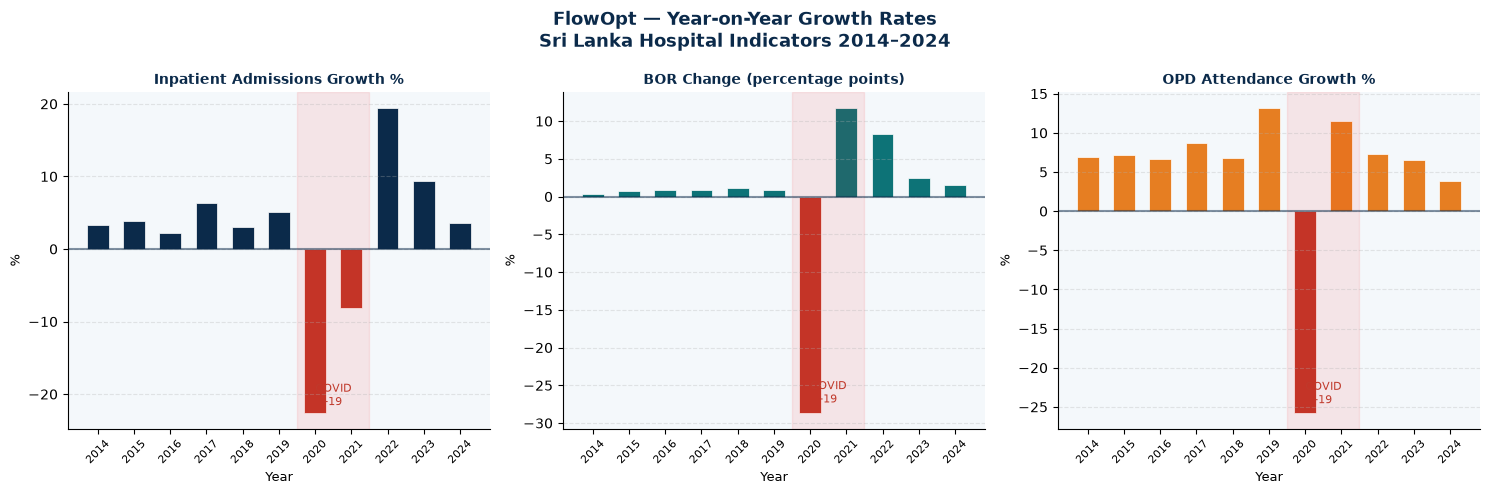

✅ Figure 5 saved:
  C:/Users/MSI/flowopt\data\processed\eda_fig5_growth_rates.png


In [12]:
fig, axes = plt.subplots(
    1, 3, figsize=(15, 5))
fig.suptitle(
    'FlowOpt — Year-on-Year Growth '
    'Rates\nSri Lanka Hospital '
    'Indicators 2014–2024',
    fontsize=13, fontweight='bold',
    color=COLORS['navy'])

growth_plots = [
    ('growth',      'Inpatient '
     'Admissions Growth %',
     COLORS['navy']),
    ('bor_growth',  'BOR Change '
     '(percentage points)',
     COLORS['teal']),
    ('opd_growth',  'OPD Attendance '
     'Growth %',
     COLORS['orange']),
]

df_growth = df_feat_clean.copy()

for ax, (col, title,
         color) in zip(
         axes, growth_plots):
    years  = df_growth['year']
    values = df_growth[col]

    bar_colors = [
        COLORS['red']
        if v < 0
        else color
        for v in values]

    bars = ax.bar(years, values,
        color=bar_colors,
        edgecolor='white',
        linewidth=0.5,
        width=0.6)

    ax.axhline(
        y=0,
        color=COLORS['navy'],
        linestyle='-',
        linewidth=1.5, alpha=0.5)

    # Shade COVID
    ax.axvspan(
        2019.5, 2021.5,
        alpha=0.08, color='red')
    ax.text(
        2020.5, values.min() * 0.95,
        'COVID\n-19',
        ha='center', fontsize=8,
        color=COLORS['red'])

    ax.set_title(title,
        fontweight='bold',
        color=COLORS['navy'],
        fontsize=10)
    ax.set_xlabel('Year', fontsize=9)
    ax.set_ylabel('%', fontsize=9)
    ax.set_facecolor(COLORS['light'])
    ax.grid(axis='y',
        alpha=0.3, linestyle='--')
    ax.set_xticks(years)
    ax.set_xticklabels(
        years, rotation=45, fontsize=8)

plt.tight_layout()
save_path = os.path.join(
    PROCESSED,
    'eda_fig5_growth_rates.png')
plt.savefig(save_path, dpi=150,
    bbox_inches='tight',
    facecolor='white')
plt.show()
print(f"✅ Figure 5 saved:\n  {save_path}")

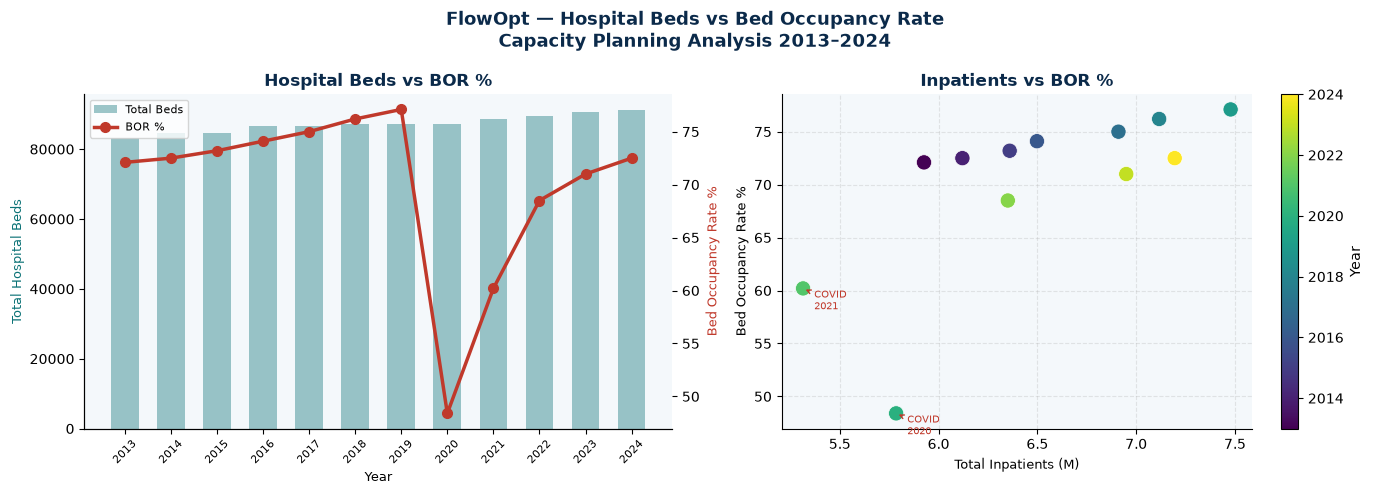

✅ Figure 6 saved:
  C:/Users/MSI/flowopt\data\processed\eda_fig6_beds_vs_bor.png


In [13]:
fig, axes = plt.subplots(
    1, 2, figsize=(14, 5))
fig.suptitle(
    'FlowOpt — Hospital Beds vs '
    'Bed Occupancy Rate\n'
    'Capacity Planning Analysis '
    '2013–2024',
    fontsize=13, fontweight='bold',
    color=COLORS['navy'])

# Left: Dual axis — beds and BOR
ax1 = axes[0]
ax2 = ax1.twinx()

ax1.bar(df['year'],
    df['beds'],
    color=COLORS['teal'],
    alpha=0.4,
    width=0.6,
    label='Total Beds')
ax2.plot(df['year'],
    df['bor'],
    'o-',
    color=COLORS['red'],
    linewidth=2.5,
    markersize=7,
    label='BOR %')

ax1.set_xlabel('Year', fontsize=9)
ax1.set_ylabel(
    'Total Hospital Beds',
    color=COLORS['teal'],
    fontsize=9)
ax2.set_ylabel(
    'Bed Occupancy Rate %',
    color=COLORS['red'],
    fontsize=9)
ax1.set_title(
    'Hospital Beds vs BOR %',
    fontweight='bold',
    color=COLORS['navy'])
ax1.set_facecolor(COLORS['light'])
ax1.set_xticks(df['year'])
ax1.set_xticklabels(
    df['year'], rotation=45,
    fontsize=8)

lines1, labels1 = (
    ax1.get_legend_handles_labels())
lines2, labels2 = (
    ax2.get_legend_handles_labels())
ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    fontsize=8)

# Right: Scatter — inpat vs bor
ax = axes[1]
scatter = ax.scatter(
    df['inpat'] / 1e6,
    df['bor'],
    c=df['year'],
    cmap='viridis',
    s=120,
    zorder=3,
    edgecolor='white',
    linewidth=0.5)

# Annotate COVID years
for _, row in df[
        df['year'].isin(
            [2020,2021])].iterrows():
    ax.annotate(
        f"COVID\n{int(row['year'])}",
        xy=(row['inpat']/1e6,
            row['bor']),
        xytext=(8, -15),
        textcoords='offset points',
        fontsize=7,
        color=COLORS['red'],
        arrowprops=dict(
            arrowstyle='->',
            color=COLORS['red'],
            lw=1))

plt.colorbar(scatter,
    ax=ax, label='Year')
ax.set_xlabel(
    'Total Inpatients (M)',
    fontsize=9)
ax.set_ylabel(
    'Bed Occupancy Rate %',
    fontsize=9)
ax.set_title(
    'Inpatients vs BOR %',
    fontweight='bold',
    color=COLORS['navy'])
ax.set_facecolor(COLORS['light'])
ax.grid(alpha=0.3, linestyle='--')

plt.tight_layout()
save_path = os.path.join(
    PROCESSED,
    'eda_fig6_beds_vs_bor.png')
plt.savefig(save_path, dpi=150,
    bbox_inches='tight',
    facecolor='white')
plt.show()
print(f"✅ Figure 6 saved:\n  {save_path}")

In [14]:
# ── Save master dataset ───────────────────────────────
master_path = os.path.join(
    PROCESSED, 'master_features.csv')

df_feat_clean.to_csv(
    master_path, index=False)

print("✅ Master features saved:")
print(f"   {master_path}")
print()
print(f"Shape: {df_feat_clean.shape}")
print(f"Columns: "
      f"{list(df_feat_clean.columns)}")
print()
print(df_feat_clean.to_string(
    index=False))

✅ Master features saved:
   C:/Users/MSI/flowopt\data\processed\master_features.csv

Shape: (11, 17)
Columns: ['year', 'inpat', 'disc_t', 'death_t', 'bor', 'ados', 'opd', 'beds', 'inpat_lag1', 'bor_lag1', 'ados_lag1', 'opd_lag1', 'growth', 'bor_growth', 'ados_growth', 'opd_growth', 'covid']

 year     inpat    disc_t  death_t  bor  ados        opd    beds  inpat_lag1  bor_lag1  ados_lag1   opd_lag1     growth  bor_growth  ados_growth  opd_growth  covid
 2014 6120470.0 6073053.0  47417.0 72.5   3.7 21000000.0 84728.0   5926125.0      72.1        3.9 19635994.0   3.279462         0.4         -0.2    6.946458      0
 2015 6359681.0 6311873.0  47808.0 73.2   3.6 22500000.0 84728.0   6120470.0      72.5        3.7 21000000.0   3.908376         0.7         -0.1    7.142857      0
 2016 6497773.0 6449753.0  48020.0 74.1   3.6 24000000.0 86589.0   6359681.0      73.2        3.6 22500000.0   2.171367         0.9          0.0    6.666667      0
 2017 6910249.0 6857911.0  52338.0 75.0   3.5 26094

In [15]:
print("="*60)
print("EDA KEY FINDINGS SUMMARY")
print("FlowOpt — Sri Lanka Hospital Data")
print("="*60)

print("""
FINDING 1 — STRONG GROWTH TREND (2013–2019)
  • Inpatient admissions grew from 5.9M 
    to 7.5M (+26.2%) over 7 years
  • OPD attendance grew from 19.6M 
    to 31.5M (+60.7%)
  • BOR increased from 72.1% to 77.1%
  • Consistent linear upward trend 
    across all indicators

FINDING 2 — COVID-19 SEVERE DISRUPTION (2020–2021)
  • Inpatient admissions dropped 22.6% 
    in 2020 (7.5M → 5.8M)
  • BOR collapsed from 77.1% to 48.4% 
    in 2020 — lowest in dataset
  • OPD attendance fell 25.8% in 2020
  • 2021 showed further decline in 
    admissions (5.3M) due to Delta wave
  • COVID flag (1 for 2020-2021) is 
    essential feature for ML models

FINDING 3 — STRONG RECOVERY (2022–2024)
  • 2022: Admissions recovered to 6.4M
  • 2023: Admissions reached 6.9M
  • 2024: Admissions at 7.2M — 
    approaching pre-COVID levels
  • BOR recovered to 72.5% by 2024

FINDING 4 — HIGH CORRELATIONS
  • Inpatients ↔ Discharges: r > 0.95
    (strong positive — as expected)
  • Inpatients ↔ OPD: r > 0.80
    (demand drives both)
  • BOR ↔ ADOS: moderate correlation
    (longer stays = higher occupancy)

FINDING 5 — DATASET CHARACTERISTICS
  • 12 total observations (2013–2024)
  • 11 usable after lag feature creation
  • No missing values in any indicator
  • Annual aggregate data only
  • Government hospitals only

FINDING 6 — MODEL IMPLICATIONS
  • Strong linear trends → supports 
    Linear Regression as baseline
  • COVID anomaly → binary flag needed
  • Lag features capture autocorrelation
  • Small dataset → LOO-CV required
  • Annual data → annual predictions only
""")

print("="*60)
print("FIGURES SAVED TO data/processed/:")
eda_figs = [
    'eda_fig1_trends.png',
    'eda_fig2_covid_impact.png',
    'eda_fig3_correlation.png',
    'eda_fig4_distributions.png',
    'eda_fig5_growth_rates.png',
    'eda_fig6_beds_vs_bor.png',
    'master_features.csv',
]
for f in eda_figs:
    fpath = os.path.join(PROCESSED, f)
    exists = os.path.exists(fpath)
    status = "✅" if exists else "❌"
    print(f"  {status} {f}")

print()
print("="*60)
print("✅ 02_EDA.ipynb COMPLETE!")
print("="*60)

EDA KEY FINDINGS SUMMARY
FlowOpt — Sri Lanka Hospital Data

FINDING 1 — STRONG GROWTH TREND (2013–2019)
  • Inpatient admissions grew from 5.9M 
    to 7.5M (+26.2%) over 7 years
  • OPD attendance grew from 19.6M 
    to 31.5M (+60.7%)
  • BOR increased from 72.1% to 77.1%
  • Consistent linear upward trend 
    across all indicators

FINDING 2 — COVID-19 SEVERE DISRUPTION (2020–2021)
  • Inpatient admissions dropped 22.6% 
    in 2020 (7.5M → 5.8M)
  • BOR collapsed from 77.1% to 48.4% 
    in 2020 — lowest in dataset
  • OPD attendance fell 25.8% in 2020
  • 2021 showed further decline in 
    admissions (5.3M) due to Delta wave
  • COVID flag (1 for 2020-2021) is 
    essential feature for ML models

FINDING 3 — STRONG RECOVERY (2022–2024)
  • 2022: Admissions recovered to 6.4M
  • 2023: Admissions reached 6.9M
  • 2024: Admissions at 7.2M — 
    approaching pre-COVID levels
  • BOR recovered to 72.5% by 2024

FINDING 4 — HIGH CORRELATIONS
  • Inpatients ↔ Discharges: r > 0.95
    